In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

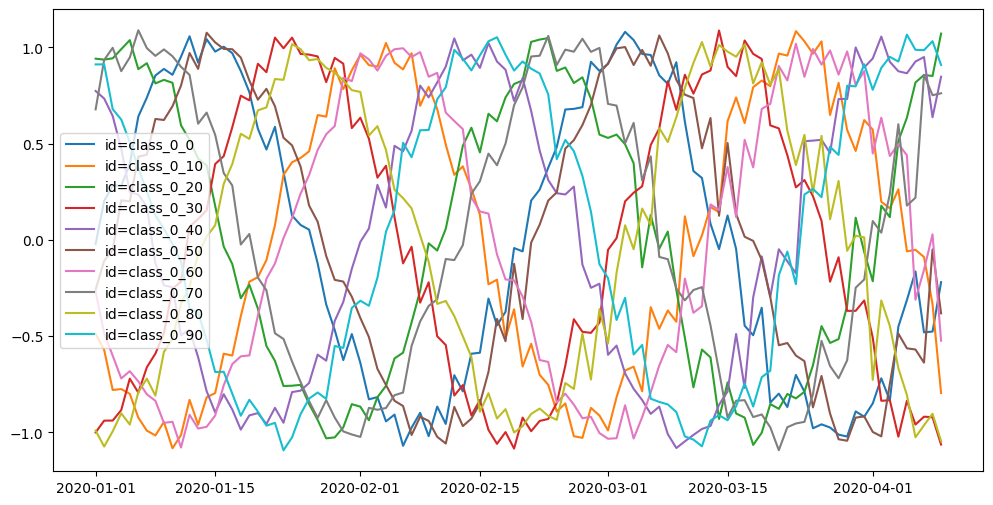

In [2]:
#dir = 'time_series_classification_easy'
dir = 'time_series_classification_hard'

import os
dfs = []
for file in os.listdir(f'../../datasets/{dir}/'):
    if file.endswith('.csv'):
        df = pd.read_csv(f'../../datasets/{dir}/{file}')
        df['date'] = pd.to_datetime(df['date'])
        df['id'] = file.split('.')[0]       
        dfs.append(df)
df = pd.concat(dfs)


to_display = ['class_0_0','class_0_10','class_0_20','class_0_30','class_0_40','class_0_50','class_0_60','class_0_70','class_0_80','class_0_90']
plt.figure(figsize=(12,6))
for i in to_display:
    plt.plot(df.loc[df['id']==i,'date'], df.loc[df['id']==i,'value'], label=f'id={i}')
plt.legend()
plt.show()

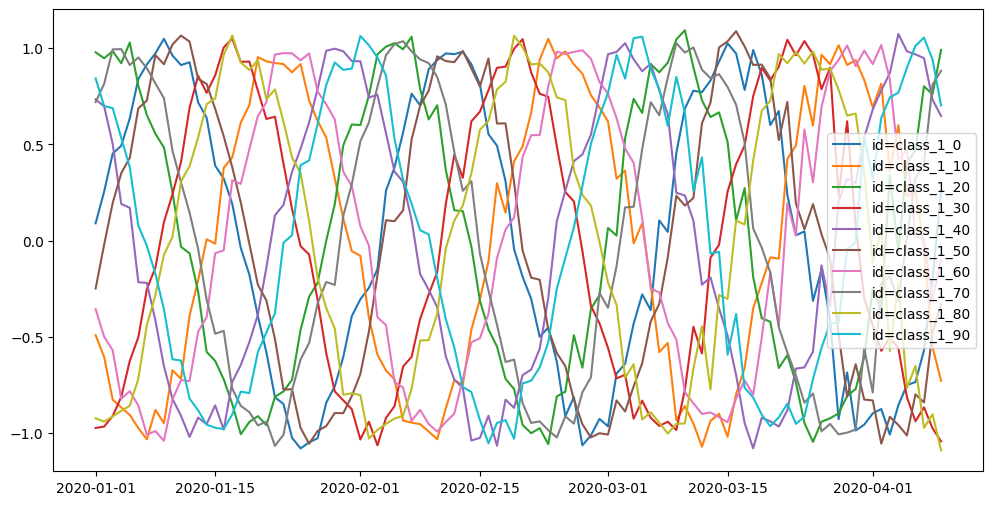

In [3]:
to_display = ['class_1_0','class_1_10','class_1_20','class_1_30','class_1_40','class_1_50','class_1_60','class_1_70','class_1_80','class_1_90']
plt.figure(figsize=(12,6))
for i in to_display:
    plt.plot(df.loc[df['id']==i,'date'], df.loc[df['id']==i,'value'], label=f'id={i}')
plt.legend()
plt.show()

In [4]:
# put df in wide format
dfw = df.pivot(index='id', columns='date', values='value').reset_index()
dfw['class'] = dfw['id'].apply(lambda x: x.split('_')[1])
dfw.drop('id', axis=1, inplace=True)
dfw.columns = [str(c)[5:10] for c in dfw.columns[1:]] + ['class']
dfw.tail()

,01-02,01-03,01-04,01-05,01-06,01-07,01-08,01-09,01-10,01-11,...,04-02,04-03,04-04,04-05,04-06,04-07,04-08,04-09,,class
195,0.706984,0.721442,0.963339,0.947975,0.960307,1.066364,1.005948,0.833890,0.778109,0.600090,...,-0.791890,-0.306624,-0.474463,-0.142057,-0.336848,0.410411,0.492098,0.489853,0.708167,1
196,1.062764,0.975860,0.776163,0.706409,0.572504,0.468640,0.212461,0.138640,-0.175573,-0.295038,...,0.345084,0.611800,0.470446,0.633519,0.713263,0.875012,0.960402,1.027532,1.013590,1
197,0.286111,0.184205,0.091249,-0.116833,-0.278692,-0.524090,-0.693598,-0.895505,-0.889048,-1.023771,...,0.796893,0.961799,0.904767,1.096458,0.883064,0.750038,0.794720,0.604542,0.352724,1
198,-0.567009,-0.676508,-0.857453,-0.914376,-1.078931,-1.065111,-1.003894,-0.869943,-0.929701,-0.768334,...,0.526413,0.548937,0.532054,0.492817,0.263227,-0.142716,-0.261236,-0.331139,-0.648829,1
199,-1.047706,-0.921510,-0.974317,-0.889583,-0.774241,-0.456884,-0.471300,-0.238261,0.088890,0.245093,...,0.083837,-0.087800,-0.722294,-0.625844,-0.794752,-0.733315,-1.020570,-0.948803,-0.964633,1


In [5]:
# classifying
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = dfw.drop('class', axis=1)
y = dfw['class'].astype('int')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train.shape = ',X_train.shape)
print('y_train.shape = ',y_train.shape)

y_train.values


X_train.shape =  (160, 100)
y_train.shape =  (160,)


array([0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1])

In [6]:

from keras.models import Model,Sequential
from keras.layers import Dense, Input

'''
model = Sequential([
Input(shape=(X_train.shape[1],)),

Dense(30, activation="relu"),
Dense(30, activation="relu"),

Dense(1, activation="sigmoid")
])
'''

input_layer = Input(shape=(X_train.shape[1],))  # Explicitly define input
# Build the model layer by layer
x = Dense(30, activation="relu")(input_layer)  # First hidden layer
x = Dense(4, activation="relu")(x)            # Second hidden layer
output_layer = Dense(1, activation="sigmoid")(x)  # Output layer
# Define the full model
model = Model(inputs=input_layer, outputs=output_layer)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         3,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,159 (12.34 KB)

 Trainable params: 3,159 (12.34 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train.values, y_train.values, epochs=100, validation_split=0.2)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.3323 - loss: 0.6740 - val_accuracy: 0.5938 - val_loss: 0.5231
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7042 - loss: 0.5945 - val_accuracy: 0.8750 - val_loss: 0.4740
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7156 - loss: 0.5686 - val_accuracy: 0.8750 - val_loss: 0.4372
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7365 - loss: 0.5331 - val_accuracy: 0.8750 - val_loss: 0.4071
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7490 - loss: 0.5304 - val_accuracy: 0.8750 - val_loss: 0.3815
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7552 - loss: 0.5097 - val_accuracy: 0.8750 - val_loss: 0.3603
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7583 - loss: 0.4713 - val_accuracy: 0.8750 - val_loss: 0.3427
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8323 - loss: 0.4450 - val_accuracy: 0.9062 - val_loss:

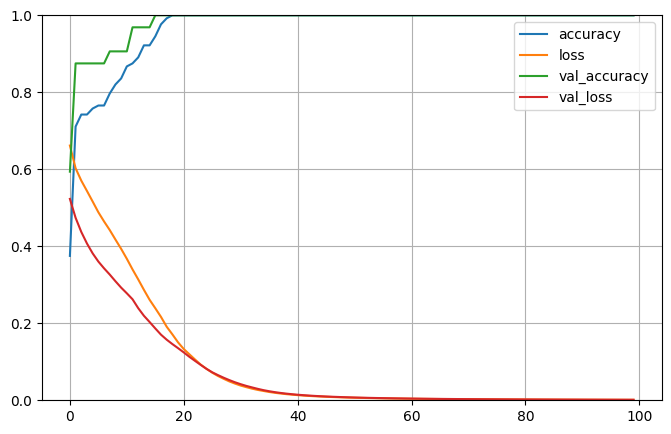

In [8]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [9]:
y_pred = model.predict(X_test)
y_pred.shape

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


(40, 1)

In [10]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
y_pred = model.predict(X_test.values)
y_pred01 = y_pred.copy()
y_pred01[y_pred >= 0.5] = 1
y_pred01[y_pred < 0.5] = 0
print(confusion_matrix(y_test, y_pred01))
print(classification_report(y_test, y_pred01))
print(accuracy_score(y_test, y_pred01)) 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[21  0]
 [ 0 19]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

1.0


In [12]:
layer = model.get_layer(name='dense_2')
weights = layer.get_weights()
print(weights)

[array([[ 0.96115196],
       [-0.54162264],
       [-0.25259376],
       [ 1.0228482 ]], dtype=float32), array([-0.10713063], dtype=float32)]


In [13]:


# Now, create a sub-model to extract the output of the second layer
second_layer_model = Model(inputs=model.input, outputs=model.layers[2].output)

# Create a sample input
sample_input = X_test.values#[1].reshape(1, -1)

# Get the output of the second layer
second_layer_output = second_layer_model.predict(sample_input)
output = model.predict(sample_input)

# Print the output
print("Model output ", output)
print("Output of the second layer:\n", second_layer_output)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Model output  [[4.1161757e-03]
 [1.0498480e-03]
 [1.1364812e-03]
 [9.9922562e-01]
 [9.9947339e-01]
 [9.9934691e-01]
 [4.9717170e-03]
 [9.9952662e-01]
 [9.9831724e-01]
 [2.0866857e-03]
 [1.1659212e-03]
 [9.9942416e-01]
 [9.9908555e-01]
 [3.3606419e-03]
 [9.9891138e-01]
 [9.9888843e-01]
 [1.3805768e-03]
 [9.9931580e-01]
 [2.5104857e-03]
 [3.3199573e-03]
 [9.9934107e-01]
 [1.2675570e-03]
 [9.9962240e-01]
 [1.5366504e-03]
 [1.5161386e-03]
 [2.2919462e-03]
 [1.0568771e-03]
 [3.1666320e-03]
 [9.9941850e-01]
 [9.9938047e-01]
 [9.2714687e-04]
 [1.3511716e-03]
 [1.6280015e-03]
 [2.9640025e-03]
 [9.9955165e-01]
 [9.9940389e-01]
 [9.9972093e-01]
 [9.9960983e-01]
 [9.9964899e-01]
 [2.1569096e-03]]
Output of the second layer:
 [[0.0000000e+00 7.1554446e+00 6.4775124e+00 1.2724712e-01]
 [0.0000000e+00 9.9060593e+00 5.4854202e+00 0.0000000e+00]
 [0.0000000e+00 9.3925648e+00 6.2722244e+00 0.0000000e+00]
 [4.0689373e+00 6.79193

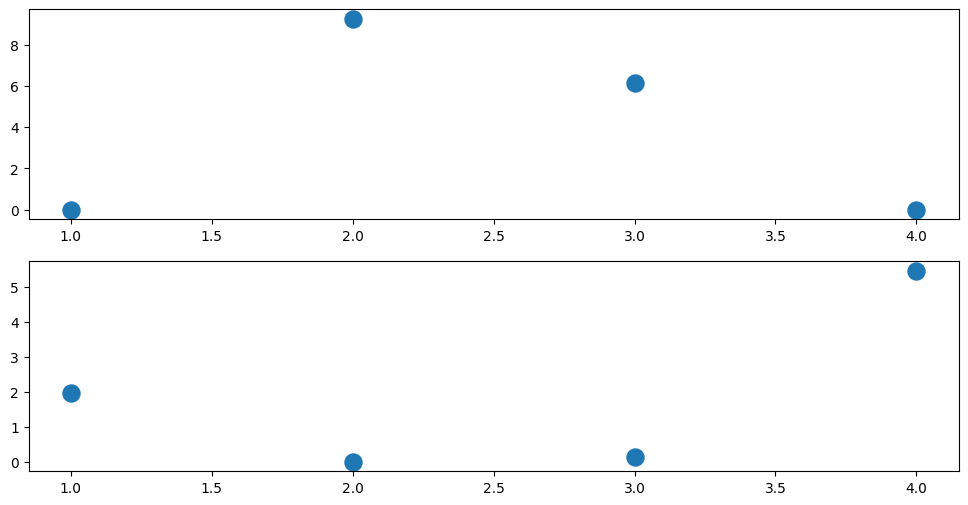

In [24]:
df = pd.DataFrame(second_layer_output)
out_df =  pd.DataFrame(output, columns=['class'])
df = pd.concat([df, out_df], axis=1)

df1 = df.loc[df['class'] >= 0.5].drop(['class'], axis=1)
df0 = df.loc[df['class'] < 0.5].drop(['class'], axis=1)

index = 10
plt.subplots(2, 1, figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.scatter([1,2,3,4],df0.values[index], s=150)
plt.subplot(2, 1, 2)
plt.scatter([1,2,3,4],df1.values[index], s = 150)
plt.show()
